In [11]:
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
from rich.progress import Progress

from fintorch.defaults import RICH_PROGRESS_COLUMNS
from fintorch.utils.args import DefaultArgumentParser
from fintorch.utils.plot import draw_candlestick_plot
from fintorch.utils.preprocess import heikin_ashi

from fintorch.deep.transform.label import ForwardHeikinAshiLabelTransform

In [2]:
args = DefaultArgumentParser.parse(args=[])

Output()

Output()

Output()

In [20]:
transform = ForwardHeikinAshiLabelTransform(symbol=args.symbol, time_frame=args.time_frame)

dc = args.online_exchange.future.data.get_data_collection(symbols=args.symbols, time_frames=args.time_frames)
sdf = dc.get_candles_df(symbol=transform.symbol, time_frame=transform.time_frame)

df = transform.transform_df(df=sdf.copy())
df.insert(0, "datetime", [datetime.fromtimestamp(ts) for ts in df.index])

print(df.label.value_counts())

df

label
True     5189
False    4873
Name: count, dtype: int64


,datetime,open,high,low,close,volume,trade,ha-close,ha-open,ha-high,ha-low,ha-color,label
timestamp,,,,,,,,,,,,,
1569412800,2019-09-25 15:30:00,8324.27,8460.00,8242.61,8293.28,9081.31,16760.00,8330.04,8308.78,8460.00,8242.61,True,False
1569427200,2019-09-25 19:30:00,8295.79,8408.31,8223.71,8346.96,6397.27,12250.00,8318.69,8319.41,8408.31,8223.71,False,False
1569441600,2019-09-25 23:30:00,8346.96,8628.44,8332.41,8430.07,9155.95,11781.00,8434.47,8319.05,8628.44,8319.05,True,False
1569456000,2019-09-26 03:30:00,8428.15,8443.55,8316.61,8361.80,4251.15,6539.00,8387.53,8376.76,8443.55,8316.61,True,False
1569470400,2019-09-26 07:30:00,8361.82,8431.00,8335.72,8379.00,3154.62,6681.00,8376.89,8382.14,8431.00,8335.72,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1714377600,2024-04-29 11:30:00,62362.10,62658.70,62150.00,62222.90,22955.75,398520.00,62348.42,62680.43,62680.43,62150.00,False,NaN
1714392000,2024-04-29 15:30:00,62222.60,63085.00,61726.20,63012.20,66488.04,956030.00,62511.50,62514.43,63085.00,61726.20,False,NaN
1714406400,2024-04-29 19:30:00,63012.20,63227.30,62511.10,62953.40,30356.74,472654.00,62926.00,62512.96,63227.30,62511.10,True,NaN


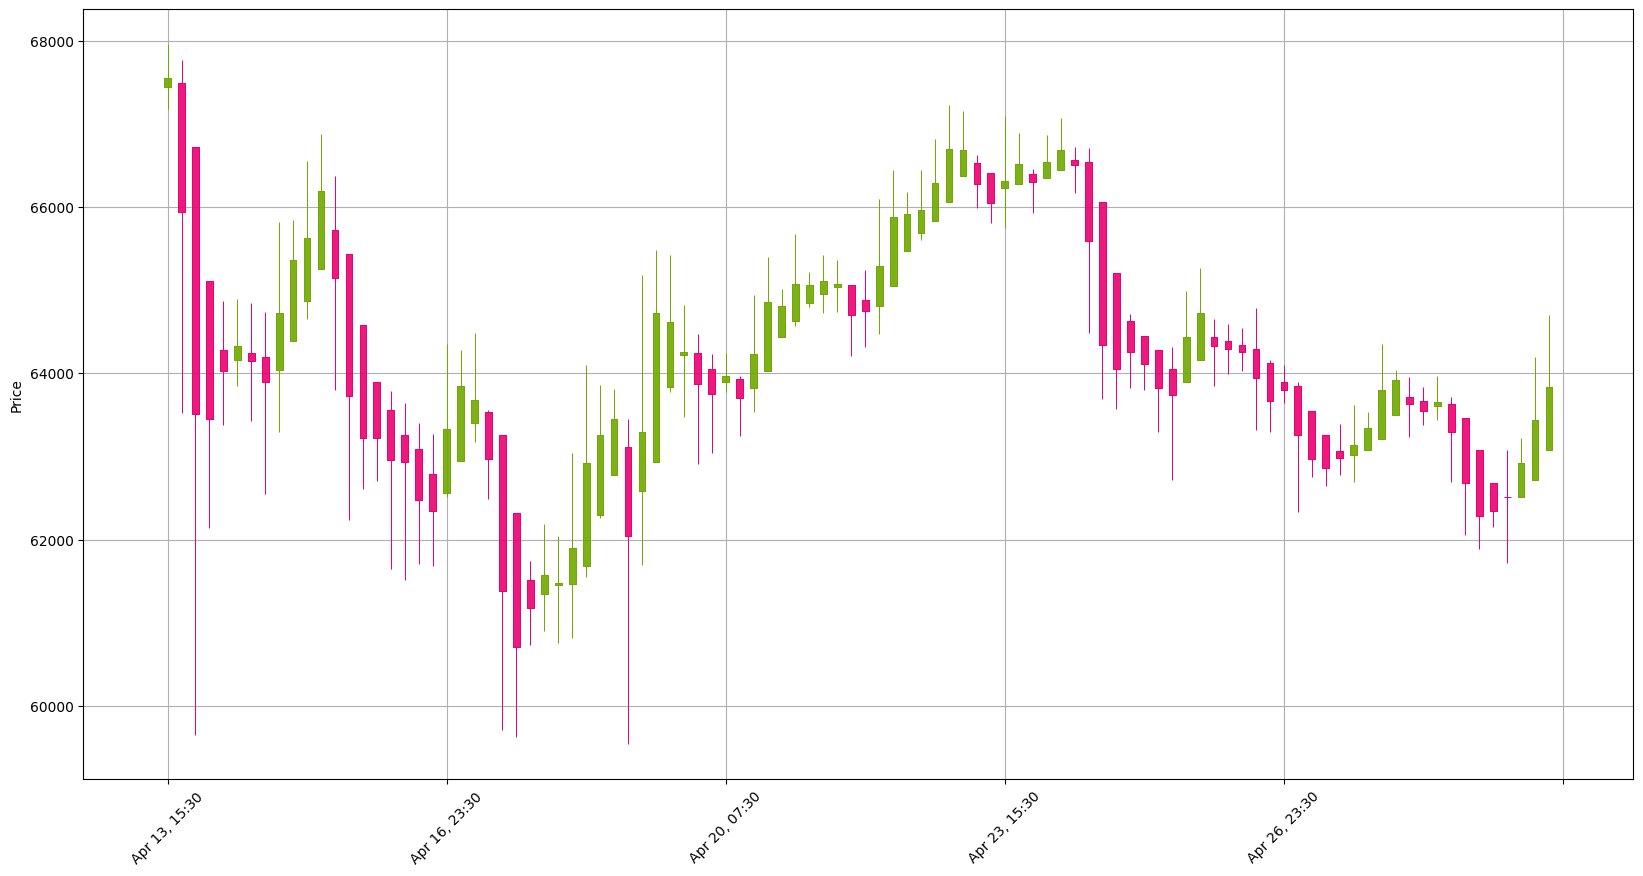

In [18]:
pdf = df.copy()[-100:]
df["open"] = df["ha-open"]
df["high"] = df["ha-high"]
df["low"] = df["ha-low"]
df["close"] = df["ha-close"]

fig, ohlc_ax = plt.subplots(nrows=1, ncols=1, figsize=(20, 10))
draw_candlestick_plot(ax=ohlc_ax, df=pdf)
ohlc_ax.grid()